In [387]:
# Al abrir Jupyter no permitia usar pandas, openpyxl o matplotlib, por lo que se instalan usando !conda install
!conda install -y pandas
!conda install -y openpyxl
!conda install -y matplotlib

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by runnin

Se crea esta celda tipo texto para traer a Jupyter las instrucciones para el proyecto.

Instrucciones generales para el reporte:

¿Cuál es el % de ausentismo total del mes?
¿Hay diferencia de ausentismo entre turno 4x3 y 7x7?
¿Cuáles son los 5 trabajadores con más ausencias?
¿Los conductores tienen un patrón diferente al resto?

In [388]:
import pandas as pd # Se importa Pandas que me permite manipular datos tipo tabla excel.
import matplotlib.pyplot as plt # Se importa para crear gráficos y visualizaciones de datos.
import numpy as np # Es la base fundamental para el cálculo numérico y científico.

In [389]:
# Cargamos los datos a la variable data usando .read_excel
data = pd.read_excel('caso1_asistencia_marzo2024.xlsx')
print(data.head()) # Verificamos que se carguen los datos de la tabla Excel

  ID_Trabajador           Nombre_Completo           RUT Tipo_Turno  \
0       TRB-069         Mario Muñoz Acuña  15.463.637-4        4x3   
1       TRB-056  Roberto Poblete Sandoval  18.150.790-K        4x3   
2       TRB-105        Héctor López Muñoz   9.041.193-4        7x7   
3       TRB-027        Andrés Bravo Reyes  16.034.686-8        4x3   
4       TRB-068    Francisco Araya Vargas  16.952.514-5        4x3   

  Nombre_Turno                     Cargo Es_Conductor       Fecha_Registro  \
0      Turno A  Técnico de Mantenimiento           No  2024-03-03 00:00:00   
1      Turno B                  Mecánico           No  2024-03-05 00:00:00   
2      Turno D              Electricista           No  2024-03-05 00:00:00   
3      Turno B        Operador de Equipo           Sí  2024-03-15 00:00:00   
4      Turno A       Supervisor de Turno           No  2024-03-05 00:00:00   

  Estado_Asistencia  
0          Presente  
1          Ausente   
2         Presente   
3               NaN  


In [390]:
# Logica 1. ¿Cuál es el % de ausentismo total del mes? 
# Guardaremos todas las filas que contengan al menos 1 dato nulo, cada caso de analisis será revisado para verificar que el nulo
# realmente afecto a la asistencia

# Paso 1. Identificar las filas que tienen al menos un dato faltante (NaN)
filas_nulas = data[data.isnull().any(axis=1)]

# Paso 2. Guardamos esas filas en un CSV separado, para posterior analisis
filas_nulas.to_csv('datos_nulos.csv', index=False)

# Paso 3. Eliminamos del DataFrame original las filas con datos duplicados.
data_limpio = data.drop_duplicates()

# Verificamos los resultados
print(f"Filas originales: {len(data)}")
print(f"Filas eliminadas (guardadas en CSV): {len(filas_nulas)}")
print(f"Filas restantes (limpias): {len(data_limpio)}")

# Paso 4. Como el original tiene formato xlsx lo pasamos a csv para visualizacion.
data_limpio.to_csv('datos_limpios.csv', index=False)


Filas originales: 2028
Filas eliminadas (guardadas en CSV): 138
Filas restantes (limpias): 2018


In [391]:
# Se realiza una revision para verificar los errores de escritura / inconsistencias entre nombres, para esto usamos .unique()
print(data_limpio['Estado_Asistencia'].unique())

<StringArray>
[       'Presente',        'Ausente ',       'Presente ',               nan,
 'Licencia Médica',        'presente',         'Ausente',               'P',
        'PRESENTE',         'Presnte',         'Permiso',     'Lic. Médica',
        'Licencia',         'AUSENTE', 'licencia medica',         'permiso',
               'A',         'ausente',        'Permiso ']
Length: 19, dtype: str


In [392]:
# Detectamos inconsistencia en los datos por lo que se procede con normalizacion.

# Realizamos un filtrado a la tabla para generar una que nos muestre unicamente a las filas que tengan a personal que se
# encuentre "Ausente", con "Licencia Medica" o "Permiso" en su Asistencia.

# Uso .str.strip() para eliminar espacios al inicio/final, .str.upper() pasa todo a mayúsculas.
data_limpio['Estado_Asistencia'] = data_limpio['Estado_Asistencia'].str.strip().str.upper()

# Usaremos un diccionario donde la clave es el valor "sucio" y el valor es la categoría final que buscamos normalizar en el remplazo
mapeo_estados = {
    'PRESENTE': 'Presente',
    'P': 'Presente',
    'AUSENTE': 'Ausente',
    'A': 'Ausente',
    'PRESNTE': 'Presente',
    'PERMISO': 'Permiso',
    'LICENCIA MÉDICA': 'Lic_Medica',
    'LICENCIA MEDICA': 'Lic_Medica',
    'LIC. MÉDICA': 'Lic_Medica',
    'LIC_MÉDICA': 'Lic_Medica',
    'LICENCIA': 'Lic_Medica',  # asumimos que "Licencia" sola = Licencia Médica
}
# Aplicamos usando un .replace para remplazar errores por valores estandar.
data_limpio['Estado_Asistencia'] = data_limpio['Estado_Asistencia'].replace(mapeo_estados)

# Incluimos los NaN a una categoría, esto para no eliminarlo ni asumirlos con algún estado.
data_limpio['Estado_Asistencia'] = data_limpio['Estado_Asistencia'].fillna('Sin_Registro')

# Verificamos que se haya realizado la limpieza.
print(data_limpio['Estado_Asistencia'].unique()) # Con esta linea revisamos valores unicos que existen a en Estado_Asistencia

<StringArray>
['Presente', 'Ausente', 'Sin_Registro', 'Lic_Medica', 'Permiso']
Length: 5, dtype: str


In [393]:
# Usamos .value_counts() para contar los valores por cada estado de asistencia
conteo_estados = data_limpio['Estado_Asistencia'].value_counts(dropna=False)
print(conteo_estados)

Estado_Asistencia
Presente        1695
Ausente          167
Lic_Medica        78
Permiso           59
Sin_Registro      19
Name: count, dtype: int64


In [394]:
# Habiendo normalizado los datos procedemos con el calculo de ausentismo.

# Creamos variable total_ausentes para asignarle una sumatoria del personal que se considerará como "Ausentes" a su jornada laboral
total_ausentes = conteo_estados['Ausente'] + conteo_estados['Lic_Medica'] + conteo_estados['Permiso']

# Calculamos el total de registros de asistencia (la suma de todas las categorías)
total_registros = conteo_estados.sum()

# Creamos variable en entero para mostrar los Sin Registro por pantalla
sn_registros = conteo_estados['Sin_Registro']

# Usando las variables anteriores calculamos el porcentaje de ausentismo
porcentaje_ausentismo = (total_ausentes / total_registros) * 100

print(f"El total de registros es: {total_registros}")
print(f"El total de ausentes es: {total_ausentes}")
print(f"Las filas sin registros son: {sn_registros}")
print(f"El porcentaje de ausentismo sería: {porcentaje_ausentismo:.1f}%") # Usamos .1f para redondear el resultado a 1 decimal.

El total de registros es: 2018
El total de ausentes es: 304
Las filas sin registros son: 19
El porcentaje de ausentismo sería: 15.1%


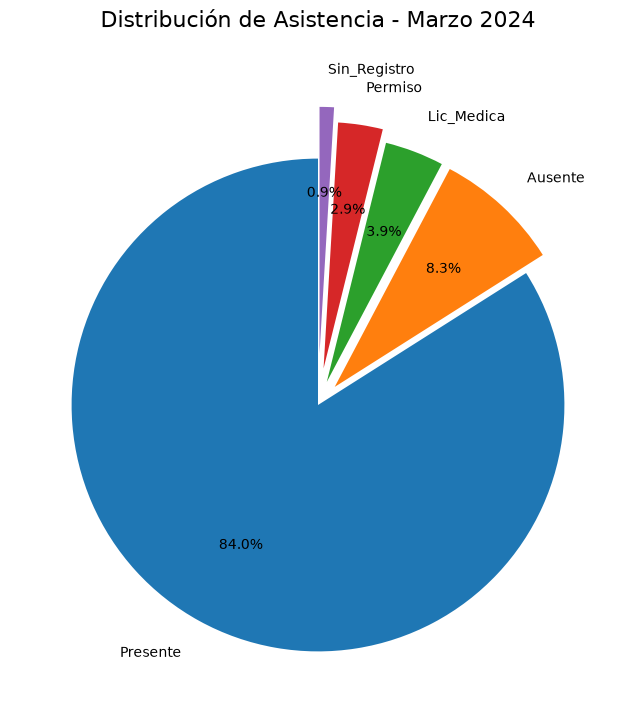

In [395]:
# Graficamos el resultado en forma de torta para mejor visualizacion
etiquetas = conteo_estados.index.tolist()   # ['Presente', 'Ausente', 'Lic_Medica', 'Permiso']
valores = conteo_estados.values.tolist()

# Un valor > 0 en explode "saca hacia afuera" x valores esa tajada del centro
explode = [0, 0.1, 0.1, 0.15, 0.21] # El orden debe coincidir con el orden de 'etiquetas'

# Configuramos el grafico
plt.figure(figsize=(8, 8))   # Esta linea ajusta el tamaño del gráfico
plt.pie(valores,
        labels = etiquetas,
        autopct = '%1.1f%%',   # Muestra el porcentaje sobre cada tajada
        explode = explode,    # Esta linea activa los variables de explode
        pctdistance = 0.65,   # pctdistance acerca los porcentaje al centro de cada tajada
        labeldistance = 1.15,  # Aleja las etiquetas de texto hacia afuera
        startangle = 90,)      # Rota el gráfico para que empiece desde arriba
plt.title('Distribución de Asistencia - Marzo 2024', fontsize=16, y=1.1)   # Escribimos el titulo del grafico y su tamaño de letra en 16
#plt.tight_layout()
plt.show()

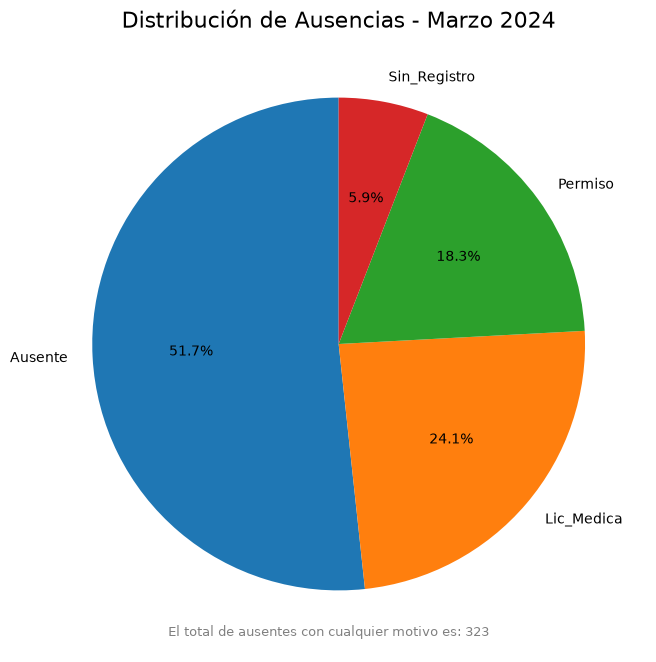

El total de registros de ausencia sería de 323
Distribuidos de la siguiente manera:
Estado_Asistencia
Ausente         167
Lic_Medica       78
Permiso          59
Sin_Registro     19
Name: count, dtype: int64


In [396]:
# Graficaremos unicamente los ausentes para evaluar y visualizar el porcentaje de motivos
# Conteo_estados ya es una serie con índice donde nombres de estados, solo necesitamos eliminar 'Presente' del índice directamente
conteo_ausencias = conteo_estados.drop('Presente')

# Extraemos etiquetas y valores desde la misma Serie (misma fuente)
etiquetas_ausentes = conteo_ausencias.index.tolist()
valores_aus = conteo_ausencias.values.tolist()

# Total de ausencias
conteo_ausencias_valor = conteo_ausencias.sum()

# Configuramos el gráfico
plt.figure(figsize=(8, 8))
plt.pie(valores_aus,
        labels=etiquetas_ausentes,
        autopct='%1.1f%%',
        startangle=90)
plt.figtext(0.5, 0.13,
            f'El total de ausentes con cualquier motivo es: {conteo_ausencias_valor}',
            ha='center', fontsize=9, color='gray')
plt.title('Distribución de Ausencias - Marzo 2024', fontsize=16)
plt.show()

print(f"El total de registros de ausencia sería de {conteo_ausencias_valor}")
print(f"Distribuidos de la siguiente manera:\n{conteo_ausencias}")

Con esto podemos confirmar que del total de 287 ausentes durante el mes de marzo del año 2024; 162 fueron sin justificativo, 73 con licencia medica y 52 con permiso.

- Ausente       167 = 51.7%
- Lic_Medica     78 = 24.1%
- Permiso        59 = 18.3%
- Sin Registro   19 = 5.9%

Total         323 = 100.0%

In [397]:
# Logica 2. Ahora busco resolver la segunda solicitud; "¿Hay diferencia de ausentismo entre turno 4x3 y 7x7?"

# Para esto usare un .groupby en el dataframe
# Groupby funciona diciendo "agrupa el DataFrame por Tipo_Turno, y de cada grupo, dame la columna Estado_Asistencia"
agrupado = data_limpio.groupby("Tipo_Turno")["Estado_Asistencia"]

cont_turno = agrupado.value_counts()
print (cont_turno)

Tipo_Turno  Estado_Asistencia
4x3         Presente             1053
            Ausente               114
            Permiso                38
            Lic_Medica             37
            Sin_Registro           13
7x7         Presente              614
            Ausente                51
            Lic_Medica             38
            Permiso                20
            Sin_Registro            6
Name: count, dtype: int64


In [398]:
# Con el conteo preliminar podemos proceder con el calculo
# Definimos qué estados cuentan como "ausencia"
estados_ausencia = ['Ausente', 'Lic_Medica', 'Permiso']

# Función que calcula el porcentaje de ausentismo para un grupo
def calcular_ausentismo(grupo):
    total = len(grupo)
    ausentes = grupo.isin(estados_ausencia).sum() # Verificamos que solo cuente los estados guardados en estados_ausencia
    return (ausentes / total) * 100

# Aplicamos la función a cada grupo (cada tipo de turno)
ausentismo_por_turno = data_limpio.groupby('Tipo_Turno')['Estado_Asistencia'].apply(calcular_ausentismo)

# Mostramos en pantalla el resultado de porcentaje de ausentimo por turno
print("El porcentaje de ausentismo por turno es:")
for turno, porcentaje in ausentismo_por_turno.items():
    print(f"{turno}: {porcentaje:.1f}%")

El porcentaje de ausentismo por turno es:
4x3: 15.1%
7x7: 15.0%


El porcentaje de cada estado por turno serian: 

Turno 4x3:
Estado_Asistencia
Presente        83.9
Ausente          9.1
Permiso          3.0
Lic_Medica       2.9
Sin_Registro     1.0
Name: count, dtype: float64

Turno 7x7:
Estado_Asistencia
Presente        84.2
Ausente          7.0
Lic_Medica       5.2
Permiso          2.7
Sin_Registro     0.8
Name: count, dtype: float64


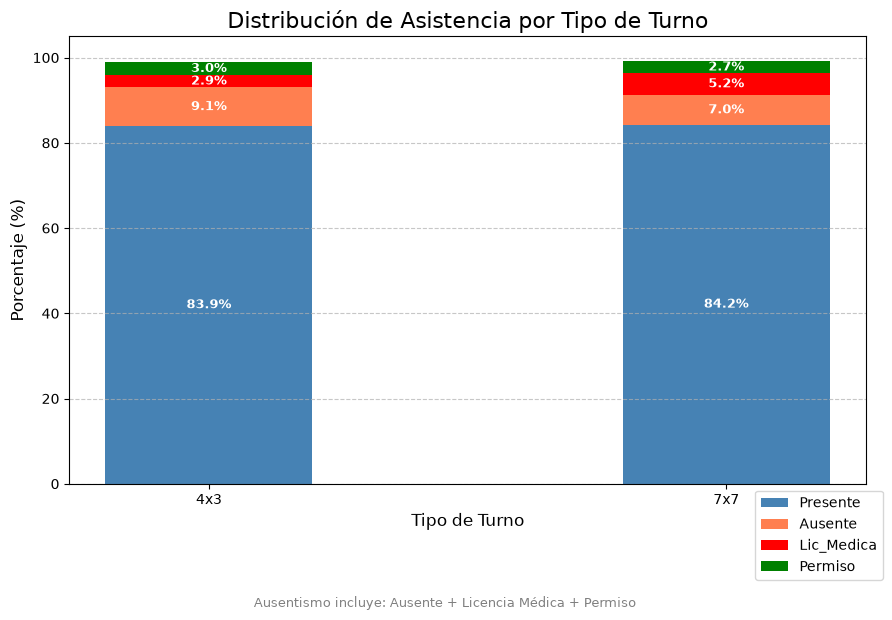

In [412]:
# Creamos un for para mostrar en pantalla el porcentaje de cada turno disponible en la lista 'turnos' (ej: ['4x3', '7x7'])
print("El porcentaje de cada estado por turno serian: ")
for turno in turnos:
    # Filtramos para obtener solo las filas del turno actual, y de esas filas extraemos únicamente la columna 'Estado_Asistencia'
    grupo = data_limpio[data_limpio['Tipo_Turno'] == turno]['Estado_Asistencia']
    print(f"\nTurno {turno}:")
    # value_counts() cuenta cuántas veces aparece cada estado en ese turno
    # Se divide por len(grupo) para convertirlo a proporción, se multiplica por 100 para obtener porcentaje
    print((grupo.value_counts() / len(grupo) * 100).round(1)) # .round(1) redondea a 1 decimal

# Lista con los nombres de los estados tal como estan en los datos normalizados
estados = ['Presente', 'Ausente', 'Lic_Medica', 'Permiso'] # El orden aquí define el orden de apilado en el gráfico de abajo hacia arriba

# Lista de colores, cada uno corresponde al estado en la misma posición de la lista anterior
colores = ['steelblue', 'coral', 'red', 'green']

# Diccionario vacío donde guardaremos los porcentajes calculados por estado
# Estructura resultante: {'Presente': [84.6, 85.1], 'Ausente': [9.4, 7.2], ...}
datos_grafico = {}

# Usamos un for para calcular su porcentaje dentro de cada turno
for estado in estados:
    # Creamos una lista vacía para este estado donde iremos agregando los porcentajes por turno
    datos_grafico[estado] = []
    
    for turno in turnos:
        # Filtramos las filas del turno actual y extraemos la columna Estado_Asistencia
        grupo = data_limpio[data_limpio['Tipo_Turno'] == turno]['Estado_Asistencia'] # (grupo == estado) genera una serie True/False por cada fila
        # .sum() cuenta los True (cada True vale 1), dando el total de ese estado en ese turno
        # Se divide por len(grupo) y se multiplica por 100 para obtener el porcentaje
        porcentaje = (grupo == estado).sum() / len(grupo) * 100
        # Agregamos el porcentaje redondeado a la lista de este estado
        datos_grafico[estado].append(round(porcentaje, 1))

# Creamos la figura y los ejes del gráfico
fig, ax = plt.subplots(figsize=(9, 6)) # fig es el lienzo completo, ax es el área donde se dibuja el gráfico

# len(turnos) define cuántas barras hay (una por turno)
base = np.zeros(len(turnos)) # Array de ceros que representa la base desde donde empieza cada barra

# Recorremos simultáneamente estados y colores usando zip()
# zip() entrega un par (estado, color) en cada iteración sin necesitar índices numéricos
for estado, color in zip(estados, colores):
    # Obtenemos la lista de porcentajes de este estado para cada turno
    valores_estado = datos_grafico[estado]

    barras = ax.bar(turnos, valores_estado, # turnos: posición en el eje X (nombre del turno), valores_estado: altura de este segmento
                    bottom=base, # bottom=base: desde qué altura empieza este segmento (clave para el apilado)
                    color=color, 
                    label=estado, # label=estado: texto que aparecerá en la leyenda para este color
                    width=0.4)
    
    # Recorremos cada barra y su valor correspondiente con enumerate+zip
    # enumerate agrega un índice numérico (i) para acceder a base[i]
    for i, (barra, valor) in enumerate(zip(barras, valores_estado)):
        # Solo etiquetamos si el segmento es mayor a 1% para evitar texto ilegible en segmentos pequeños
        if valor > 0.5:
            ax.text(
                barra.get_x() + barra.get_width() / 2,  # Centro horizontal de la barra
                base[i] + valor / 2,   # Centro vertical del segmento: base + la mitad de su altura
                f'{valor:.1f}%',       # Texto a mostrar, formateado con 1 decimal
                ha='center',           # Alineación horizontal centrada
                va='center',           # Alineación vertical centrada
                fontsize=9,
                fontweight='bold',
                color='white')         # Blanco para que contraste con el color del segmento
    
    # Sumamos los valores de este estado a la base para que el próximo estado empiece justo donde este terminó, esto es lo que crea el 
    # efecto apilado
    base += np.array(valores_estado) # np.array() permite sumar los dos arrays elemento a elemento (posición por posición)

ax.set_title('Distribución de Asistencia por Tipo de Turno', fontsize=16) # Título del gráfico
ax.set_xlabel('Tipo de Turno', fontsize=12) # Etiqueta del eje X
ax.set_ylabel('Porcentaje (%)', fontsize=12) # Etiqueta del eje Y
ax.set_ylim(0, 105) # Límite del eje Y: de 0 a 105 para que el 100% no quede pegado al borde superior
ax.legend(loc='upper right', bbox_to_anchor=(1.03, 0)) # Leyenda posicionada fuera del gráfico a la derecha
ax.grid(axis='y', linestyle='--', alpha=0.7) # Cuadrícula solo en el eje Y, punteada y semi-transparente para no tapar las barras

# Nota al pie fuera del área del gráfico
plt.figtext(0.5, -0.02,
            'Ausentismo incluye: Ausente + Licencia Médica + Permiso',
            ha='center', fontsize=9, color='gray') # ha='center' centra el texto, 0.5 en X es el centro horizontal de la figura
plt.tight_layout() # Ajusta automáticamente los márgenes para que ningún elemento quede cortado

plt.show() # Muestra el gráfico en pantalla


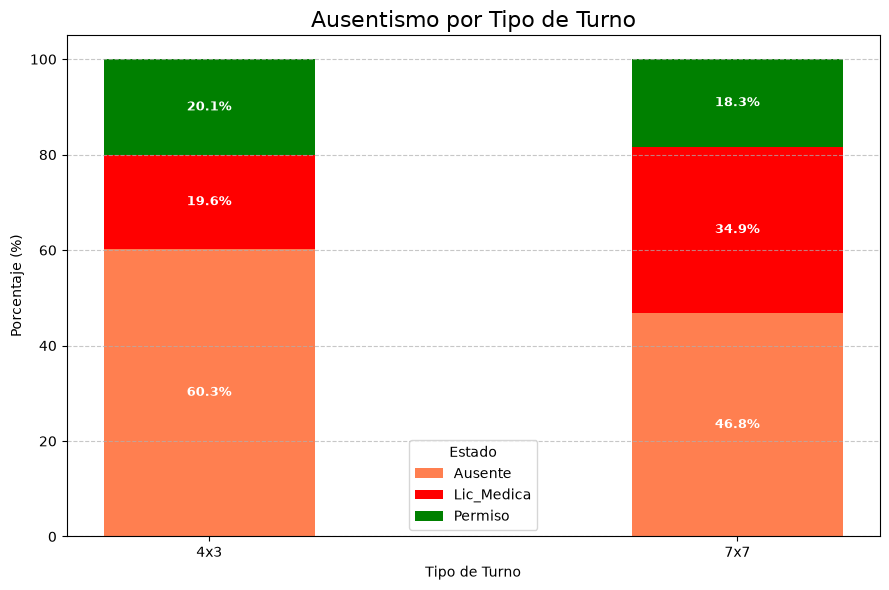

In [450]:
# Nuevamente graficaremos unicamente los ausentes para comprobar los motivos de ausentismos
estados_ausentes = ['Ausente', 'Lic_Medica', 'Permiso'] # Definimos un grupo de estados para considerarlos "Ausentes"

datos_grafico = {} # Creamos un diccionario vacio para guardar los datos del grafico

for estado in estados_ausentes:
    datos_grafico[estado] = []
    for turno in turnos:
        grupo = data_limpio[data_limpio['Tipo_Turno'] == turno]['Estado_Asistencia']
        # Solo los registros considerados ausentismo
        grupo_ausentes = grupo[grupo.isin(estados_ausentes)]
        porcentaje = (
            (grupo_ausentes == estado).sum()
            / len(grupo_ausentes)
            * 100)
        datos_grafico[estado].append(round(porcentaje, 1))

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(9,6))
base = np.zeros(len(turnos))
for estado, color in zip(estados_ausentes, colores):
    valores = datos_grafico[estado]
    barras = ax.bar(
        turnos,
        valores,
        bottom=base,
        color=color,
        label=estado,
        width=0.4)

    for i, (barra, valor) in enumerate(zip(barras, valores)): # Crearemos las etiquetas del Grafico y su configuracion
        if valor > 0.5:
            ax.text(
                barra.get_x() + barra.get_width()/2,
                base[i] + valor/2,
                f'{valor:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold')
    base += np.array(valores)

ax.set_title('Ausentismo por Tipo de Turno', fontsize=16)
ax.set_xlabel('Tipo de Turno')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, max(base) + 5)
ax.legend(title='Estado')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Resultados: Teniendo en cuenta los datos obtenidos;
 
4x3         - Presente             1053 = 83.9%
            - Ausente               114 = 9.1%
            - Permiso                38 = 3.0%
            - Lic_Medica             37 = 2.9%
            - Sin_Registro           13 = 1.0%

            Total                1255 = 100%

            
7x7         - Presente              614 = 84.2%
            - Ausente                51 = 7.0%
            - Permiso                20 = 2.7%
            - Lic_Medica             38 = 5.2%
            - Sin_Registro            6 = 0.8%

            Total                 729 = 100%

El ausentimo injustificado es mayor en el turno 4x3, donde tiene 114 registros, representando el 9.1%, a comparacion del turno 7x7 que tiene 51 registros, siendo el 7.0% de los registros.
El porcentaje de registros de Licencia Medica es mayor en en el turno 7x7, alcanzando un 5.2% de su turno, mientras que el turno 4x3 se queda en un 2.9%.

In [451]:
# Logica 3. ¿Cuáles son los 5 trabajadores con más ausencias?

# Para saber esto creare una tabla usando solamente los datos donde estén los ausentes
solo_ausentes = data_limpio[data_limpio['Estado_Asistencia'].isin(['Ausente', 'Lic_Medica', 'Permiso'])]

# Con la tabla nueva lo agrupamos por ID_Trabajador, Nombre_Completo y contamos cuantas filas tiene cada trabajador
cont_top5 = solo_ausentes.groupby(["ID_Trabajador", "Nombre_Completo"])["Estado_Asistencia"].count()

# Ordenamos de mayor a menor y tomamos los primeros 5 usando .head()
top5 = cont_top5.sort_values(ascending = False).head(5)

print (top5)

ID_Trabajador  Nombre_Completo        
TRB-092        Gabriel Poblete López      6
TRB-038        Alfredo Salas Pérez        6
TRB-040        Gonzalo Herrera Cortés     6
TRB-008        Sebastián Muñoz Salas      6
TRB-036        Esteban Cisternas Acuña    5
Name: Estado_Asistencia, dtype: int64


El top 5 de los trabajadores con mas ausencias durante el mes de Marzo 2024 serian los siguientes:

ID_Trabajador  Nombre_Completo        
TRB-092        Gabriel Poblete López      6
TRB-038        Alfredo Salas Pérez        6
TRB-040        Gonzalo Herrera Cortés     6
TRB-008        Sebastián Muñoz Salas      6
TRB-036        Esteban Cisternas Acuña    5}

Nota: "Ausencias" en cada usuario toman en cuenta tanto ausencias injustificadas, licencias medicas, y los permisos. 

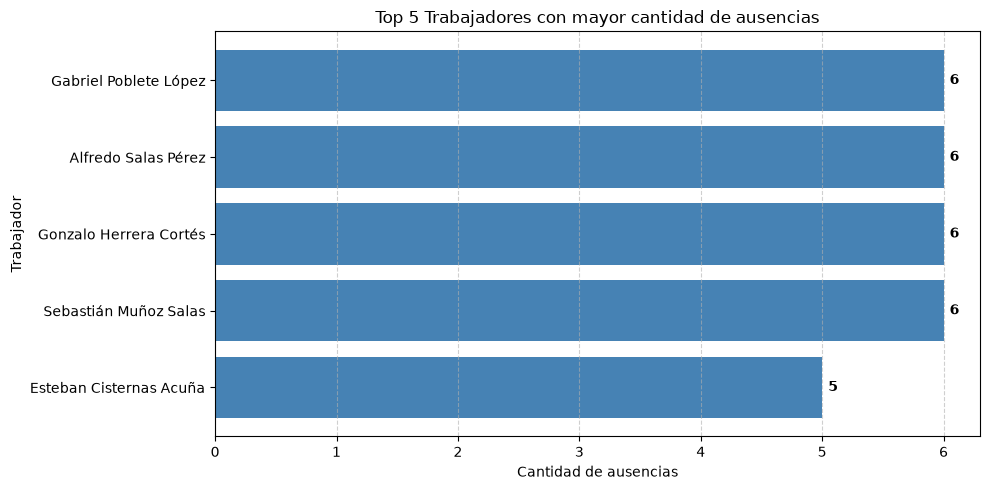

In [455]:
# Crearemos el grafico para ver mas claro los datos

top5_df = top5.reset_index(name='Cantidad_Ausencias') # Para poder graficar este resultado es necesario pasarlo a DataFrame
fig, ax = plt.subplots(figsize=(10,5)) # Definimos tamaños
ax.barh(
    top5_df["Nombre_Completo"],
    top5_df["Cantidad_Ausencias"],
    color="steelblue")
ax.invert_yaxis() # Mostramos el mayor arriba

# Etiquetas sobre cada barra
for i, valor in enumerate(top5_df["Cantidad_Ausencias"]):
    ax.text(
        valor + 0.05,
        i,
        str(valor),
        va="center",
        fontsize=10,
        fontweight="bold")

ax.set_title("Top 5 Trabajadores con mayor cantidad de ausencias")
ax.set_xlabel("Cantidad de ausencias")
ax.set_ylabel("Trabajador")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [401]:
# Logica 4. ¿Los conductores tienen un patrón distinto al resto?

# Revisamos que no haya errores de escritura en los datos
print(data_limpio['Es_Conductor'].unique())

<StringArray>
['No', 'Sí']
Length: 2, dtype: str


In [402]:
# Descubrimos que no hay errores, sin embargo hay que tener en cuenta que el Si, lleva tilde en los datos; "Sí"

# Se crea una tabla usando solamente los datos donde estén los conductores, para esto verificamos que buscamos que los datos que tengan 
# la columna Es_Conductor en "Sí"
solo_conductores = data_limpio[data_limpio["Es_Conductor"] == 'Sí']

# Con la tabla nueva lo agrupamos por Estado_Asistencia y usando.value_counts() contamos cuantas filas tiene cada estado
cont_conductores = solo_conductores["Estado_Asistencia"].value_counts()

# Mostramos por pantalla el resultado de los conductores
print("El registro de asistencia de los conductores sería: ")
print(cont_conductores)

El registro de asistencia de los conductores sería: 
Estado_Asistencia
Presente        265
Ausente          23
Lic_Medica        8
Sin_Registro      7
Permiso           5
Name: count, dtype: int64


Recordando que los datos de ausencia generales de todo el personal era el siguiente:

- El total de registros es: 1890
- El total de ausentes es: 287
- El porcentaje de ausentismo sería: 15.2%

Podemos decir que el porcentaje de ausentismo de los conductores es menor, ya que de 285 conductores tenemos un total de 36 ausentes,
representando el 12.6%

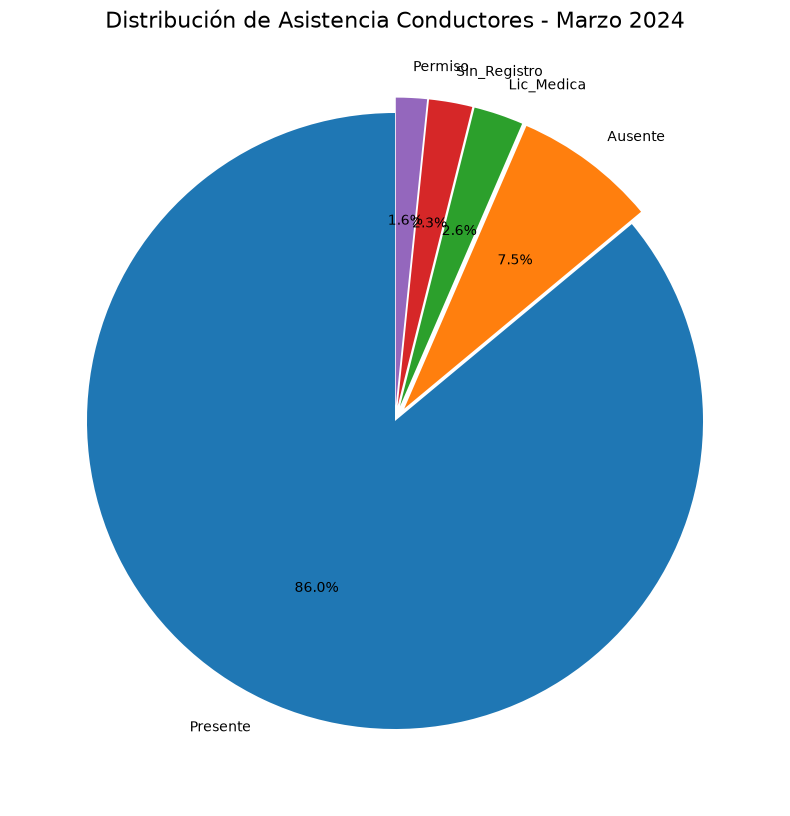

In [404]:
# Graficamos el resultado en un grafico tipo torta para comparar ambos resultados
etiquetas_conduct = cont_conductores.index.tolist()   # ['Presente', 'Ausente', 'Lic_Medica', 'Permiso']
valores_conduct = cont_conductores.values.tolist()    # [249, 23, 8, 5]

# Un valor > 0 en explode sacará esa tajada del centro
explode = [0, 0.05, 0.05, 0.05, 0.05] # El orden debe coincidir con el orden de 'etiquetas'

# Configuramos el grafico
plt.figure(figsize=(10, 10))   # Esta linea ajusta el tamaño del gráfico
plt.pie(valores_conduct,
        labels = etiquetas_conduct,
        autopct = '%1.1f%%',   # Muestra el porcentaje sobre cada tajada
        explode = explode,    # Esta linea activa los variables de explode
        startangle = 90,)      # Rota el gráfico para que empiece desde arriba
plt.title('Distribución de Asistencia Conductores - Marzo 2024', fontsize=16)   # Escribimos el titulo del grafico y su tamaño de letra
plt.show()

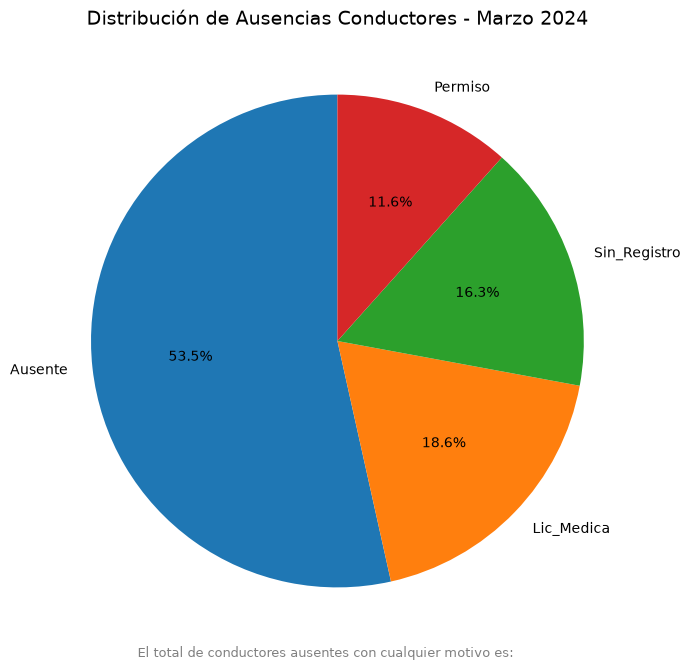

El total de registros de ausencia de los conductores sería de 43
Distribuidos de la siguiente manera Estado_Asistencia
Ausente         23
Lic_Medica       8
Sin_Registro     7
Permiso          5
Name: count, dtype: int64


In [422]:
# Graficaremos unicamente los ausentes para evaluar y visualizar el porcentaje de motivos
# Para esto creare una tabla usando solamente los datos donde estén los conductores ausentes
solo_conduct_ausentes = solo_conductores[solo_conductores['Estado_Asistencia'].isin(['Ausente', 'Lic_Medica', 'Permiso', 'Sin_Registro'])]

# Contamos cuántas veces aparece cada estado en solo_conduct_ausentes
conteo_ausencias_conduct = solo_conduct_ausentes['Estado_Asistencia'].value_counts()

# A esta variable creada le hacemos sum() para sumar sus registros
conteo_ausencias_valor = conteo_ausencias_conduct.sum()

# Extraemos etiquetas (nombres de estados) y valores (conteos) desde la Serie
etiquetas_aus_conduct = conteo_ausencias_conduct.index.tolist()   # ['Ausente', 'Lic_Medica', 'Permiso']
valores_aus_conduct = conteo_ausencias_conduct.values.tolist()    # [23, 8, 5]

# Configuramos el gráfico
plt.figure(figsize=(8, 8))
plt.pie(valores_aus_conduct,
        labels=etiquetas_aus_conduct,
        autopct='%1.1f%%',
        startangle=90)
plt.figtext(0.5, 0.1,
            'El total de conductores ausentes con cualquier motivo es: ',
            ha='center', fontsize=9, color='gray') # ha='center' centra el texto, 0.5 en X es el centro horizontal de la figura
plt.title('Distribución de Ausencias Conductores - Marzo 2024', fontsize=14)
plt.show()

# Mostramos por pantalla el resultado de los conductores
print(f"El total de registros de ausencia de los conductores sería de {conteo_ausencias_valor}")
print(f"Distribuidos de la siguiente manera {conteo_ausencias_conduct}")

Con esto podemos confirmar que del total de 43 conductores ausentes durante el mes de marzo del año 2024; 23 fueron sin justificativo, 8 con licencia medica y 5 con permiso, se encontraron 5 Sin registro.

AUSENTES CONDUCTORES

- Ausente         23 = 53.5%
- Lic_Medica       8 = 18.6%
- Sin_Registro     7 = 16.3%
- Permiso          5 = 11.6%

- Total           43 = 100.0%

Los porcentajes de ausencias en general del personal eran los siguientes

AUSENTES GENERAL

- Ausente       167 = 51.7%
- Lic_Medica     78 = 24.1%
- Permiso        59 = 18.3%
- Sin Registro   19 = 5.9%
- Total         323 = 100.0%

De estas tablas podemos analizar que los Ausentes injustificados son más en los conductores, mientras que aquellos que fallan con motivos de lic. Medica o con permiso son menores en conductores en comparacion al resto del personal.